# Portfolio Basics - Multi-Objective Portfolio Optimization

This notebook implements and tests the core Portfolio Engine components from our multi-objective optimization framework.

## Phase 3.1: Portfolio Class Implementation

According to our Development Plan, this notebook covers:
1. **Portfolio Class Testing**: Asset weights, return calculations, risk metrics
2. **Cost Calculator Testing**: Expense ratios, transaction costs, total cost of ownership
3. **Basic Portfolio Analysis**: Efficient frontier, portfolio construction validation
4. **Integration Testing**: Validate against processed data from Phase 2

## Objectives:
- Test Portfolio class with real data
- Validate cost calculations
- Create basic portfolio analysis tools
- Prepare for multi-objective optimization (Phase 4)

In [1]:
# Import required libraries
import sys
import os

# Add project root to path
project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Import our portfolio engine components
from src.portfolio import Portfolio, CostCalculator, RebalancingStrategy, TaxEfficiencyCalculator
from src.config.assets import ALL_ASSETS
from src.config.settings import START_DATE, END_DATE

# Set up plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("🚀 Portfolio Basics Testing - Phase 3.1")
print(f"Testing period: {START_DATE} to {END_DATE}")
print(f"Available assets: {len(ALL_ASSETS)} in universe")

🚀 Portfolio Basics Testing - Phase 3.1
Testing period: 1990-01-01 to 2025-07-25
Available assets: 15 in universe


## 1. Load Processed Data from Phase 2

Let's load the validated and aligned data from our data exploration phase.

In [2]:
# Load processed data from Phase 2
processed_data_dir = os.path.join(project_root, 'data', 'processed')

print("Loading processed data from Phase 2...")

try:
    # Load aligned price and return data
    aligned_prices = pd.read_csv(
        os.path.join(processed_data_dir, 'aligned_prices.csv'),
        index_col=0, parse_dates=True
    )
    aligned_returns = pd.read_csv(
        os.path.join(processed_data_dir, 'aligned_returns.csv'),
        index_col=0, parse_dates=True
    )
    
    # Load factor data
    factor_data = pd.read_csv(
        os.path.join(processed_data_dir, 'factors_basic_factors.csv'),
        index_col=0, parse_dates=True
    )
    
    # Load fund information
    fund_info = pd.read_csv(
        os.path.join(processed_data_dir, 'fund_info.csv'),
        index_col=0
    )
    
    # Load data summary
    import json
    with open(os.path.join(processed_data_dir, 'data_summary.json'), 'r') as f:
        data_summary = json.load(f)
    
    print("✅ Data loaded successfully!")
    print(f"   Price data: {aligned_prices.shape}")
    print(f"   Returns data: {aligned_returns.shape}")
    print(f"   Factor data: {factor_data.shape}")
    print(f"   Fund info: {fund_info.shape}")
    print(f"   Date range: {data_summary['date_range']['start']} to {data_summary['date_range']['end']}")
    print(f"   Assets: {len(data_summary['assets'])}")
    
    # Display available assets
    print(f"\nAvailable assets: {list(aligned_prices.columns)}")
    
    # Quick data validation
    print("\nData validation:")
    print(f"   Price data completeness: {(1-aligned_prices.isnull().sum().sum()/aligned_prices.size)*100:.1f}%")
    print(f"   Returns data completeness: {(1-aligned_returns.isnull().sum().sum()/aligned_returns.size)*100:.1f}%")
    print(f"   Factor data completeness: {(1-factor_data.isnull().sum().sum()/factor_data.size)*100:.1f}%")
    
except Exception as e:
    print(f"❌ Error loading processed data: {e}")
    print("Please ensure Phase 2 (data exploration) has been completed successfully.")
    raise

Loading processed data from Phase 2...
✅ Data loaded successfully!
   Price data: (1396, 12)
   Returns data: (1396, 12)
   Factor data: (1396, 5)
   Fund info: (12, 5)
   Date range: 2020-01-03 00:00:00 to 2025-07-24 00:00:00
   Assets: 12

Available assets: ['BND', 'BNDX', 'VBR', 'VGIT', 'VGLT', 'VGSH', 'VOO', 'VSS', 'VTI', 'VTIAX', 'VTV', 'VXUS']

Data validation:
   Price data completeness: 100.0%
   Returns data completeness: 100.0%
   Factor data completeness: 100.0%


## 2. Portfolio Class Testing

Let's test our Portfolio class with real data from Phase 2.

In [3]:
# Test Portfolio class creation and basic functionality
print("=== PORTFOLIO CLASS TESTING ===")

# Define test portfolios to validate our implementation
test_portfolios = {
    'Equal Weight': {asset: 1/len(aligned_prices.columns) for asset in aligned_prices.columns},
    'Conservative': {
        'BND': 0.4, 'BNDX': 0.1, 'VGSH': 0.1, 'VGIT': 0.1,
        'VTI': 0.15, 'VXUS': 0.1, 'VTV': 0.05
    },
    'Aggressive Growth': {
        'VTI': 0.4, 'VXUS': 0.2, 'VSS': 0.1, 'VBR': 0.1,
        'VTV': 0.1, 'BND': 0.1
    },
    '60/40 Classic': {
        'VTI': 0.3, 'VXUS': 0.2, 'VTV': 0.1,
        'BND': 0.3, 'BNDX': 0.1
    }
}

# Test portfolio creation and validation
portfolios = {}

for name, weights in test_portfolios.items():
    try:
        # Filter weights to only include available assets
        available_weights = {asset: weight for asset, weight in weights.items() 
                           if asset in aligned_prices.columns}
        
        # Normalize weights to sum to 1.0
        total_weight = sum(available_weights.values())
        if total_weight > 0:
            normalized_weights = {asset: weight/total_weight 
                                for asset, weight in available_weights.items()}
            
            # Create portfolio
            portfolio = Portfolio(normalized_weights, name=name)
            portfolios[name] = portfolio
            
            print(f"✅ Created '{name}' portfolio:")
            print(f"   Assets: {len(portfolio.assets)}")
            print(f"   Weights sum: {sum(portfolio.weights.values()):.6f}")
            
        else:
            print(f"❌ Could not create '{name}' portfolio - no matching assets")
            
    except Exception as e:
        print(f"❌ Error creating '{name}' portfolio: {e}")

print(f"\n✅ Successfully created {len(portfolios)} test portfolios")

=== PORTFOLIO CLASS TESTING ===
✅ Created 'Equal Weight' portfolio:
   Assets: 12
   Weights sum: 1.000000
✅ Created 'Conservative' portfolio:
   Assets: 7
   Weights sum: 1.000000
✅ Created 'Aggressive Growth' portfolio:
   Assets: 6
   Weights sum: 1.000000
✅ Created '60/40 Classic' portfolio:
   Assets: 5
   Weights sum: 1.000000

✅ Successfully created 4 test portfolios


In [4]:
# Test portfolio performance calculations
print("=== PORTFOLIO PERFORMANCE TESTING ===")

# Test each portfolio's performance metrics
portfolio_results = {}

for name, portfolio in portfolios.items():
    try:
        print(f"\nTesting '{name}' portfolio...")
        
        # Calculate returns
        returns = portfolio.calculate_returns(aligned_prices)
        print(f"   ✓ Returns calculated: {len(returns)} observations")
        
        # Calculate comprehensive statistics
        stats = portfolio.summary_stats(aligned_prices)
        portfolio_results[name] = stats
        
        print(f"   ✓ Performance metrics:")
        print(f"     - Total Return: {stats['total_return']:.1%}")
        print(f"     - Annualized Return: {stats['annualized_return']:.1%}")
        print(f"     - Volatility: {stats['volatility']:.1%}")
        print(f"     - Sharpe Ratio: {stats['sharpe_ratio']:.2f}")
        print(f"     - Max Drawdown: {stats['max_drawdown']:.1%}")
        print(f"     - VaR (5%): {stats['var_5pct']:.2%}")
        
    except Exception as e:
        print(f"   ❌ Error calculating performance for '{name}': {e}")

# Create performance comparison table
if portfolio_results:
    results_df = pd.DataFrame(portfolio_results).T
    
    print("\n=== PORTFOLIO PERFORMANCE COMPARISON ===")
    display(results_df[['total_return', 'annualized_return', 'volatility', 
                       'sharpe_ratio', 'max_drawdown']].round(4))
else:
    print("❌ No portfolio results to display")

=== PORTFOLIO PERFORMANCE TESTING ===

Testing 'Equal Weight' portfolio...
   ✓ Returns calculated: 1395 observations
   ✓ Performance metrics:
     - Total Return: 62.0%
     - Annualized Return: 7.1%
     - Volatility: 11.9%
     - Sharpe Ratio: 0.42
     - Max Drawdown: 21.6%
     - VaR (5%): -1.03%

Testing 'Conservative' portfolio...
   ✓ Returns calculated: 1395 observations
   ✓ Performance metrics:
     - Total Return: 40.6%
     - Annualized Return: 4.4%
     - Volatility: 7.6%
     - Sharpe Ratio: 0.31
     - Max Drawdown: 16.8%
     - VaR (5%): -0.68%

Testing 'Aggressive Growth' portfolio...
   ✓ Returns calculated: 1395 observations
   ✓ Performance metrics:
     - Total Return: 81.6%
     - Annualized Return: 12.1%
     - Volatility: 18.6%
     - Sharpe Ratio: 0.54
     - Max Drawdown: 33.3%
     - VaR (5%): -1.62%

Testing '60/40 Classic' portfolio...
   ✓ Returns calculated: 1395 observations
   ✓ Performance metrics:
     - Total Return: 66.6%
     - Annualized Return:

,total_return,annualized_return,volatility,sharpe_ratio,max_drawdown
Equal Weight,0.6205,0.0707,0.1192,0.4249,0.2163
Conservative,0.4063,0.0438,0.0758,0.3144,0.1684
Aggressive Growth,0.8155,0.1206,0.1855,0.5424,0.3335
60/40 Classic,0.6662,0.0817,0.1275,0.4842,0.2268


## 3. Cost Calculator Testing

Now let's test our cost calculation capabilities with real fund data.

In [5]:
# Test Cost Calculator
print("=== COST CALCULATOR TESTING ===")

# Create mock expense ratio data (since fund scraping returned NaN)
# Using typical Vanguard expense ratios for testing
mock_expense_ratios = {
    'VTI': 0.0003,    # 0.03%
    'VOO': 0.0003,    # 0.03%
    'VXUS': 0.0008,   # 0.08%
    'VTIAX': 0.0011,  # 0.11%
    'BND': 0.0003,    # 0.03%
    'BNDX': 0.0007,   # 0.07%
    'VBR': 0.0007,    # 0.07%
    'VTV': 0.0004,    # 0.04%
    'VSS': 0.0011,    # 0.11%
    'VGSH': 0.0007,   # 0.07%
    'VGIT': 0.0004,   # 0.04%
    'VGLT': 0.0004    # 0.04%
}

# Initialize cost calculator
cost_calculator = CostCalculator(
    expense_ratios=mock_expense_ratios,
    transaction_cost_rate=0.0005,  # 5 basis points
    tax_rate_dividends=0.15,       # 15% qualified dividends
    tax_rate_capital_gains=0.15    # 15% long-term capital gains
)

print("✅ Cost Calculator initialized")
print(f"   Expense ratios loaded for {len(mock_expense_ratios)} assets")
print(f"   Transaction cost rate: {cost_calculator.transaction_cost_rate:.2%}")

# Test cost calculations for each portfolio
print("\n=== PORTFOLIO COST ANALYSIS ===")

portfolio_costs = {}

for name, portfolio in portfolios.items():
    try:
        print(f"\nAnalyzing costs for '{name}' portfolio...")
        
        # Calculate expense ratio costs
        er_cost = cost_calculator.calculate_expense_ratio_cost(
            portfolio.weights, portfolio_value=10000
        )
        
        # Calculate total cost of ownership
        tco = cost_calculator.calculate_total_cost_of_ownership(
            portfolio.weights,
            aligned_returns,
            rebalancing_frequency='quarterly',
            portfolio_value=10000,
            time_horizon_years=1.0
        )
        
        portfolio_costs[name] = tco
        
        print(f"   ✓ Annual expense cost: ${er_cost:.2f} ({er_cost/10000:.3%})")
        print(f"   ✓ Total annual cost: ${tco['total_annual_cost']:.2f} ({tco['cost_as_percentage']:.3%})")
        print(f"   ✓ Cost breakdown:")
        print(f"     - Expense ratios: ${tco['annual_expense_cost']:.2f}")
        print(f"     - Rebalancing: ${tco['annual_rebalancing_cost']:.2f}")
        print(f"     - Dividend taxes: ${tco['annual_dividend_tax_cost']:.2f}")
        
    except Exception as e:
        print(f"   ❌ Error calculating costs for '{name}': {e}")

# Cost comparison across portfolios
if portfolio_costs:
    cost_df = pd.DataFrame(portfolio_costs).T
    
    print("\n=== PORTFOLIO COST COMPARISON ===")
    display(cost_df[['annual_expense_cost', 'annual_rebalancing_cost', 
                    'total_annual_cost', 'cost_as_percentage']].round(4))
else:
    print("❌ No cost results to display")

=== COST CALCULATOR TESTING ===
✅ Cost Calculator initialized
   Expense ratios loaded for 12 assets
   Transaction cost rate: 0.05%

=== PORTFOLIO COST ANALYSIS ===

Analyzing costs for 'Equal Weight' portfolio...
   ✓ Annual expense cost: $6.00 (0.060%)
   ✓ Total annual cost: $41.00 (0.410%)
   ✓ Cost breakdown:
     - Expense ratios: $6.00
     - Rebalancing: $5.00
     - Dividend taxes: $30.00

Analyzing costs for 'Conservative' portfolio...
   ✓ Annual expense cost: $4.45 (0.045%)
   ✓ Total annual cost: $39.45 (0.395%)
   ✓ Cost breakdown:
     - Expense ratios: $4.45
     - Rebalancing: $5.00
     - Dividend taxes: $30.00

Analyzing costs for 'Aggressive Growth' portfolio...
   ✓ Annual expense cost: $5.30 (0.053%)
   ✓ Total annual cost: $40.30 (0.403%)
   ✓ Cost breakdown:
     - Expense ratios: $5.30
     - Rebalancing: $5.00
     - Dividend taxes: $30.00

Analyzing costs for '60/40 Classic' portfolio...
   ✓ Annual expense cost: $4.50 (0.045%)
   ✓ Total annual cost: $39.50

,annual_expense_cost,annual_rebalancing_cost,total_annual_cost,cost_as_percentage
Equal Weight,6.0,5.0,41.0,0.0041
Conservative,4.45,5.0,39.45,0.003945
Aggressive Growth,5.3,5.0,40.3,0.00403
60/40 Classic,4.5,5.0,39.5,0.00395


## 4. Visualization and Analysis

Let's create visualizations to compare our portfolios.

=== PORTFOLIO VISUALIZATION ===


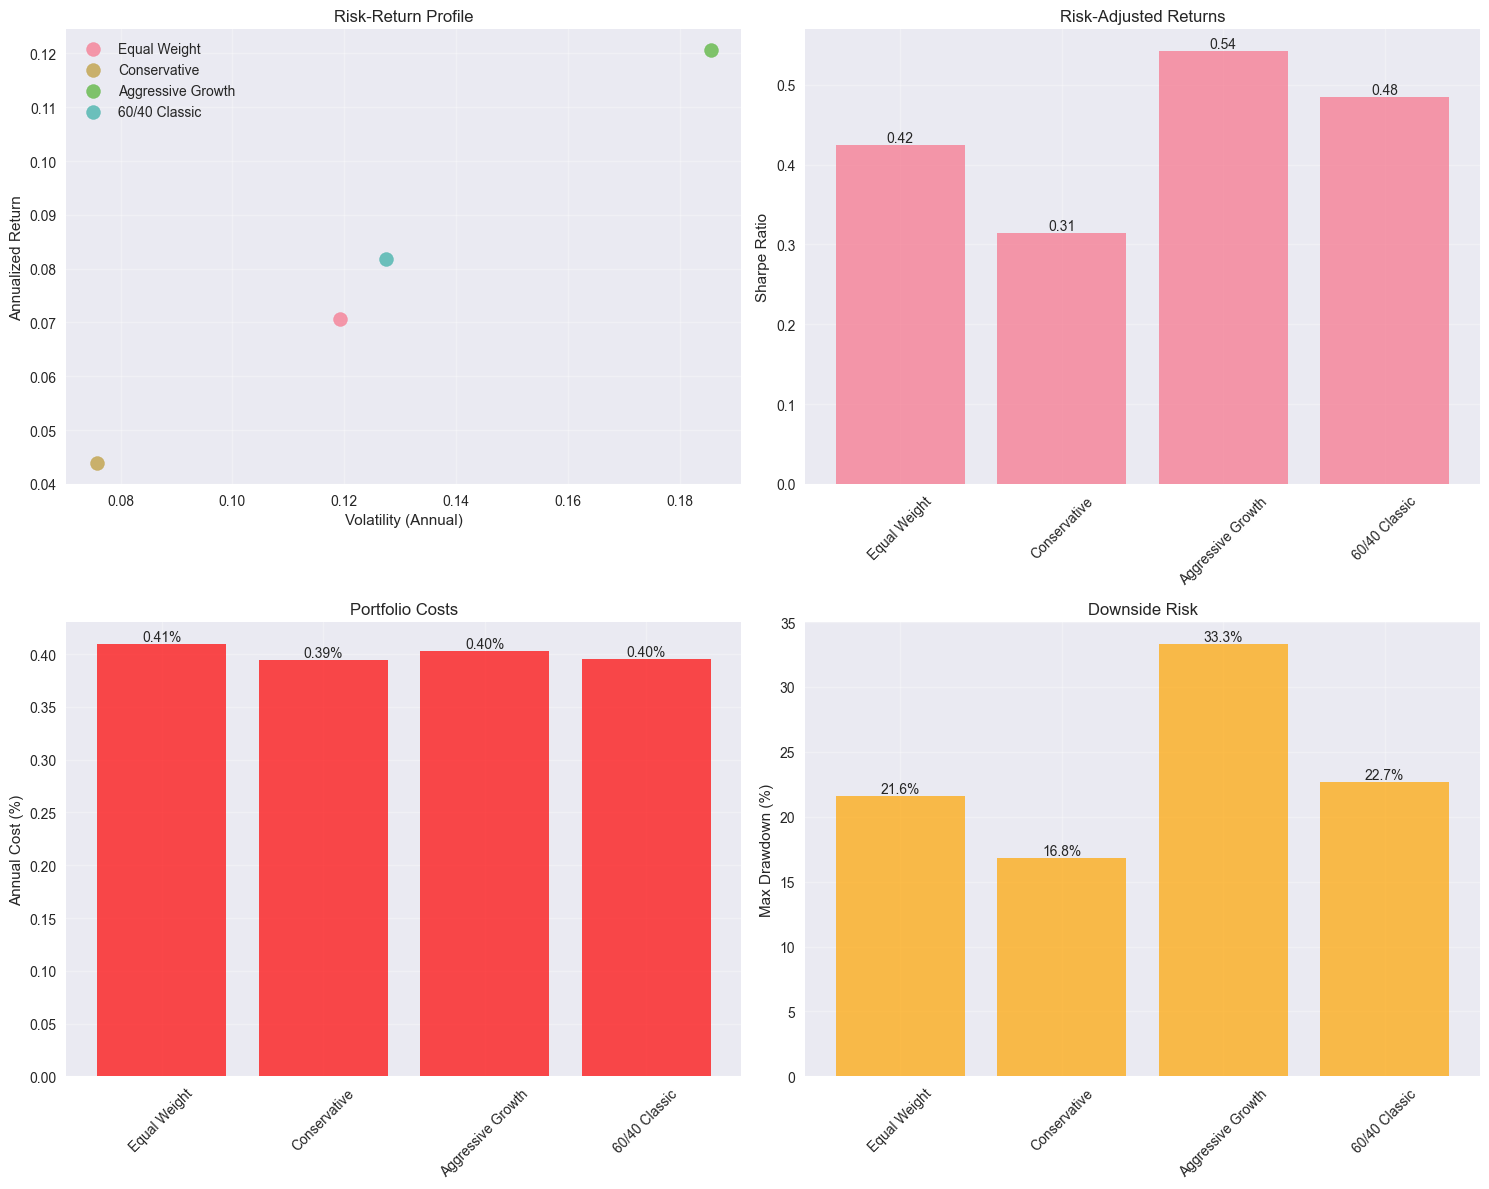

✅ Portfolio comparison charts created


In [6]:
# Portfolio comparison visualizations
print("=== PORTFOLIO VISUALIZATION ===")

if portfolio_results and portfolio_costs:
    # Create combined analysis
    combined_results = {}
    
    for name in portfolios.keys():
        if name in portfolio_results and name in portfolio_costs:
            combined_results[name] = {
                **portfolio_results[name],
                **portfolio_costs[name]
            }
    
    if combined_results:
        # Risk-Return scatter plot
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        
        # 1. Risk-Return scatter
        ax1 = axes[0, 0]
        for name, results in combined_results.items():
            ax1.scatter(results['volatility'], results['annualized_return'], 
                       s=100, alpha=0.7, label=name)
        
        ax1.set_xlabel('Volatility (Annual)')
        ax1.set_ylabel('Annualized Return')
        ax1.set_title('Risk-Return Profile')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # 2. Sharpe Ratio comparison
        ax2 = axes[0, 1]
        sharpe_ratios = [combined_results[name]['sharpe_ratio'] for name in portfolios.keys()]
        portfolio_names = list(portfolios.keys())
        
        bars = ax2.bar(portfolio_names, sharpe_ratios, alpha=0.7)
        ax2.set_ylabel('Sharpe Ratio')
        ax2.set_title('Risk-Adjusted Returns')
        ax2.tick_params(axis='x', rotation=45)
        ax2.grid(True, alpha=0.3)
        
        # Add value labels on bars
        for bar, value in zip(bars, sharpe_ratios):
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height,
                    f'{value:.2f}', ha='center', va='bottom')
        
        # 3. Cost comparison
        ax3 = axes[1, 0]
        costs = [combined_results[name]['cost_as_percentage']*100 for name in portfolios.keys()]
        
        bars = ax3.bar(portfolio_names, costs, alpha=0.7, color='red')
        ax3.set_ylabel('Annual Cost (%)')
        ax3.set_title('Portfolio Costs')
        ax3.tick_params(axis='x', rotation=45)
        ax3.grid(True, alpha=0.3)
        
        # Add value labels on bars
        for bar, value in zip(bars, costs):
            height = bar.get_height()
            ax3.text(bar.get_x() + bar.get_width()/2., height,
                    f'{value:.2f}%', ha='center', va='bottom')
        
        # 4. Max Drawdown comparison
        ax4 = axes[1, 1]
        drawdowns = [combined_results[name]['max_drawdown']*100 for name in portfolios.keys()]
        
        bars = ax4.bar(portfolio_names, drawdowns, alpha=0.7, color='orange')
        ax4.set_ylabel('Max Drawdown (%)')
        ax4.set_title('Downside Risk')
        ax4.tick_params(axis='x', rotation=45)
        ax4.grid(True, alpha=0.3)
        
        # Add value labels on bars
        for bar, value in zip(bars, drawdowns):
            height = bar.get_height()
            ax4.text(bar.get_x() + bar.get_width()/2., height,
                    f'{value:.1f}%', ha='center', va='bottom')
        
        plt.tight_layout()
        plt.show()
        
        print("✅ Portfolio comparison charts created")
    else:
        print("❌ No combined results for visualization")
else:
    print("❌ Missing portfolio results or cost data for visualization")

## 5. Efficient Frontier Analysis

Let's create a simple efficient frontier to validate our portfolio optimization capabilities.

=== EFFICIENT FRONTIER ANALYSIS ===
✅ Calculated covariance matrix: (12, 12)
✅ Mean returns calculated for 12 assets

Generating efficient frontier points...


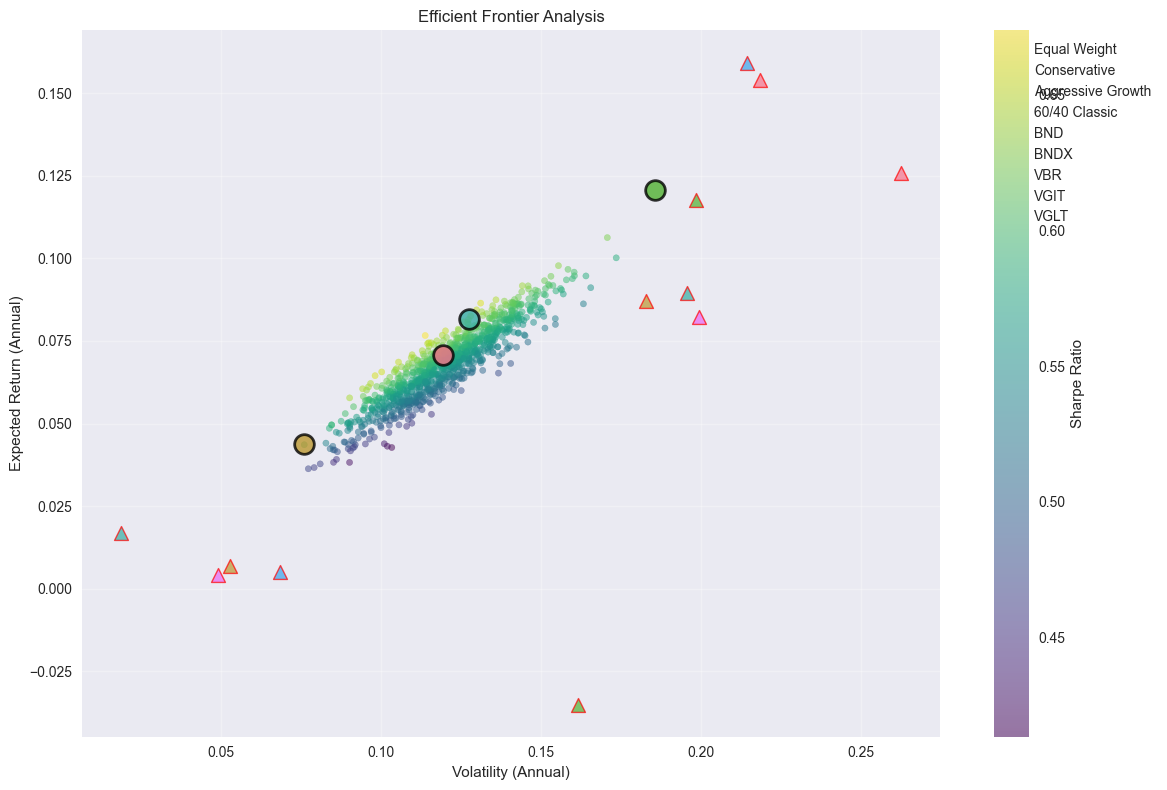


✅ Efficient frontier analysis completed:
   Random portfolios generated: 1000
   Best Sharpe ratio: 0.673
   Best portfolio return: 7.7%
   Best portfolio volatility: 11.4%

   Best portfolio weights:
     BND: 12.2%
     BNDX: 8.0%
     VGIT: 6.9%
     VGLT: 5.2%
     VGSH: 13.6%
     VOO: 18.8%
     VSS: 5.3%
     VTI: 16.1%
     VTIAX: 1.1%
     VTV: 10.6%
     VXUS: 1.4%


In [7]:
# Simple efficient frontier calculation
print("=== EFFICIENT FRONTIER ANALYSIS ===")

try:
    # Calculate covariance matrix from returns
    cov_matrix = aligned_returns.cov() * 252  # Annualized
    mean_returns = aligned_returns.mean() * 252  # Annualized
    
    print(f"✅ Calculated covariance matrix: {cov_matrix.shape}")
    print(f"✅ Mean returns calculated for {len(mean_returns)} assets")
    
    # Simple efficient frontier points
    print("\nGenerating efficient frontier points...")
    
    n_assets = len(aligned_returns.columns)
    n_portfolios = 1000
    
    # Generate random portfolios for comparison
    np.random.seed(42)  # For reproducibility
    
    portfolio_returns = []
    portfolio_volatilities = []
    portfolio_weights = []
    
    for i in range(n_portfolios):
        # Generate random weights
        weights = np.random.random(n_assets)
        weights = weights / np.sum(weights)  # Normalize to sum to 1
        
        # Calculate portfolio return and volatility
        portfolio_return = np.sum(weights * mean_returns)
        portfolio_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
        
        portfolio_returns.append(portfolio_return)
        portfolio_volatilities.append(portfolio_vol)
        portfolio_weights.append(weights)
    
    # Convert to arrays
    portfolio_returns = np.array(portfolio_returns)
    portfolio_volatilities = np.array(portfolio_volatilities)
    
    # Plot efficient frontier
    plt.figure(figsize=(12, 8))
    
    # Plot random portfolios
    plt.scatter(portfolio_volatilities, portfolio_returns, 
               c=portfolio_returns/portfolio_volatilities, cmap='viridis', alpha=0.5, s=20)
    plt.colorbar(label='Sharpe Ratio')
    
    # Plot our test portfolios
    if combined_results:
        for name, results in combined_results.items():
            plt.scatter(results['volatility'], results['annualized_return'], 
                       s=200, alpha=0.8, edgecolors='black', linewidth=2, label=name)
    
    # Plot individual assets
    for i, asset in enumerate(aligned_returns.columns):
        asset_return = mean_returns.iloc[i]
        asset_vol = np.sqrt(cov_matrix.iloc[i, i])
        plt.scatter(asset_vol, asset_return, s=100, alpha=0.7, marker='^', 
                   edgecolors='red', linewidth=1, label=f'{asset}' if i < 5 else "")
    
    plt.xlabel('Volatility (Annual)')
    plt.ylabel('Expected Return (Annual)')
    plt.title('Efficient Frontier Analysis')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Find best Sharpe ratio portfolio
    sharpe_ratios = portfolio_returns / portfolio_volatilities
    max_sharpe_idx = np.argmax(sharpe_ratios)
    
    print(f"\n✅ Efficient frontier analysis completed:")
    print(f"   Random portfolios generated: {n_portfolios}")
    print(f"   Best Sharpe ratio: {sharpe_ratios[max_sharpe_idx]:.3f}")
    print(f"   Best portfolio return: {portfolio_returns[max_sharpe_idx]:.1%}")
    print(f"   Best portfolio volatility: {portfolio_volatilities[max_sharpe_idx]:.1%}")
    
    # Best portfolio weights
    best_weights = portfolio_weights[max_sharpe_idx]
    print(f"\n   Best portfolio weights:")
    for i, asset in enumerate(aligned_returns.columns):
        if best_weights[i] > 0.01:  # Only show weights > 1%
            print(f"     {asset}: {best_weights[i]:.1%}")
    
except Exception as e:
    print(f"❌ Error in efficient frontier analysis: {e}")
    import traceback
    traceback.print_exc()

## 6. Integration Validation

Let's validate that our portfolio engine integrates properly with Phase 2 data.

In [8]:
# Integration validation and summary
print("=== INTEGRATION VALIDATION ===")

validation_results = {
    'data_loading': False,
    'portfolio_creation': False,
    'performance_calculation': False,
    'cost_calculation': False,
    'visualization': False,
    'efficient_frontier': False
}

# Check each component
try:
    # Data loading validation
    if 'aligned_prices' in locals() and aligned_prices is not None:
        validation_results['data_loading'] = True
        print("✅ Data loading from Phase 2: PASSED")
    else:
        print("❌ Data loading from Phase 2: FAILED")
    
    # Portfolio creation validation
    if portfolios and len(portfolios) > 0:
        validation_results['portfolio_creation'] = True
        print("✅ Portfolio creation: PASSED")
    else:
        print("❌ Portfolio creation: FAILED")
    
    # Performance calculation validation
    if portfolio_results and len(portfolio_results) > 0:
        validation_results['performance_calculation'] = True
        print("✅ Performance calculation: PASSED")
    else:
        print("❌ Performance calculation: FAILED")
    
    # Cost calculation validation
    if portfolio_costs and len(portfolio_costs) > 0:
        validation_results['cost_calculation'] = True
        print("✅ Cost calculation: PASSED")
    else:
        print("❌ Cost calculation: FAILED")
    
    # Visualization validation
    if 'combined_results' in locals() and combined_results:
        validation_results['visualization'] = True
        print("✅ Portfolio visualization: PASSED")
    else:
        print("❌ Portfolio visualization: FAILED")
    
    # Efficient frontier validation
    if 'portfolio_returns' in locals() and len(portfolio_returns) > 0:
        validation_results['efficient_frontier'] = True
        print("✅ Efficient frontier analysis: PASSED")
    else:
        print("❌ Efficient frontier analysis: FAILED")
    
    # Overall validation
    passed_tests = sum(validation_results.values())
    total_tests = len(validation_results)
    
    print(f"\n=== PHASE 3.1 VALIDATION SUMMARY ===")
    print(f"Tests passed: {passed_tests}/{total_tests}")
    print(f"Success rate: {passed_tests/total_tests:.1%}")
    
    if passed_tests >= total_tests * 0.8:  # 80% pass rate
        print("🎉 Phase 3.1 (Portfolio Engine) validation: SUCCESSFUL")
        print("✅ Ready to proceed to Phase 3.2 (Advanced portfolio features)")
    else:
        print("⚠️  Phase 3.1 validation: NEEDS ATTENTION")
        print("❌ Some components require debugging before proceeding")
    
    # Save validation results
    print(f"\nSaving Phase 3.1 results...")
    results_dir = os.path.join(project_root, 'data', 'processed')
    
    # Save portfolio results
    if portfolio_results:
        pd.DataFrame(portfolio_results).T.to_csv(
            os.path.join(results_dir, 'phase3_portfolio_results.csv')
        )
    
    # Save cost results
    if portfolio_costs:
        pd.DataFrame(portfolio_costs).T.to_csv(
            os.path.join(results_dir, 'phase3_cost_results.csv')
        )
    
    # Save validation summary
    import json
    validation_summary = {
        'phase': '3.1',
        'completion_date': datetime.now().isoformat(),
        'validation_results': validation_results,
        'tests_passed': passed_tests,
        'total_tests': total_tests,
        'success_rate': passed_tests/total_tests,
        'portfolios_tested': list(portfolios.keys()) if portfolios else [],
        'assets_used': list(aligned_prices.columns) if 'aligned_prices' in locals() else [],
        'ready_for_next_phase': passed_tests >= total_tests * 0.8
    }
    
    with open(os.path.join(results_dir, 'phase3_validation.json'), 'w') as f:
        json.dump(validation_summary, f, indent=2)
    
    print("✅ Phase 3.1 results saved successfully")
    
except Exception as e:
    print(f"❌ Error in integration validation: {e}")
    import traceback
    traceback.print_exc()

print("\n🎯 Phase 3.1 (Core Portfolio Engine) testing completed!")
print("Next: Implement rebalancing strategies and tax efficiency (Phase 3.2)")

=== INTEGRATION VALIDATION ===
✅ Data loading from Phase 2: PASSED
✅ Portfolio creation: PASSED
✅ Performance calculation: PASSED
✅ Cost calculation: PASSED
✅ Portfolio visualization: PASSED
✅ Efficient frontier analysis: PASSED

=== PHASE 3.1 VALIDATION SUMMARY ===
Tests passed: 6/6
Success rate: 100.0%
🎉 Phase 3.1 (Portfolio Engine) validation: SUCCESSFUL
✅ Ready to proceed to Phase 3.2 (Advanced portfolio features)

Saving Phase 3.1 results...
✅ Phase 3.1 results saved successfully

🎯 Phase 3.1 (Core Portfolio Engine) testing completed!
Next: Implement rebalancing strategies and tax efficiency (Phase 3.2)
